In [1]:
!pip install -q langchain langchain-community langchain-text-splitters chromadb sentence-transformers beautifulsoup4 requests lxml


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import time
import requests
from bs4 import BeautifulSoup

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

c:\Users\mallo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Document list

In [3]:
documents_info = [
    {"topic": "Chest Pain", "source": "MedlinePlus", "url": "https://medlineplus.gov/ency/article/003079.htm", "category": "Common Symptom", "date": "2024-05-08"},
    {"topic": "Fever", "source": "MedlinePlus", "url": "https://medlineplus.gov/fever.html", "category": "Common Symptom", "date": "2025-07-27"},
    {"topic": "Headache", "source": "WHO", "url": "https://www.who.int/news-room/fact-sheets/detail/headache-disorders", "category": "Common Symptom", "date": "2025-10-24"},
    {"topic": "Cough", "source": "NHS", "url": "https://www.nhs.uk/symptoms/cough/", "category": "Common Symptom", "date": "2023-12-08"},
    {"topic": "Shortness of Breath", "source": "NHS", "url": "https://www.nhs.uk/conditions/shortness-of-breath/", "category": "Common Symptom", "date": "2024-01-30"},
    {"topic": "Abdominal Pain", "source": "MedlinePlus", "url": "https://medlineplus.gov/abdominalpain.html", "category": "Common Symptom", "date": "2025-09-23"},
    {"topic": "Vomiting and Diarrhea", "source": "NHS", "url": "https://www.nhs.uk/conditions/diarrhoea-and-vomiting/", "category": "Common Symptom", "date": "2023-12-21"},
    {"topic": "Sore Throat", "source": "CDC", "url": "https://www.cdc.gov/sore-throat/about/index.html", "category": "Common Symptom", "date": "2024-04-17"},
    {"topic": "Burns and Scalds", "source": "NHS", "url": "https://www.nhs.uk/conditions/burns-and-scalds/", "category": "Common Symptom", "date": "2022-06-23"},
    {"topic": "Cuts and Scrapes", "source": "MedlinePlus", "url": "https://medlineplus.gov/firstaid.html", "category": "Common Symptom", "date": "2026-01-25"},

    {"topic": "Sprains", "source": "NHS", "url": "https://www.nhs.uk/conditions/sprains-and-strains/", "category": "Common Symptom", "date": "2024-04-23"},
    {"topic": "Allergic Reaction (Anaphylaxis)", "source": "MedlinePlus", "url": "https://medlineplus.gov/ency/article/000844.htm", "category": "Edge Case", "date": "2024-03-31"},
    {"topic": "Fever in Infants", "source": "NHS", "url": "https://www.nhs.uk/conditions/fever-in-children/", "category": "Edge Case", "date": "2024-01-03"},
    {"topic": "Stroke Symptoms", "source": "CDC", "url": "https://www.cdc.gov/stroke/signs-symptoms/", "category": "Edge Case", "date": "2024-10-24"},
    {"topic": "Sepsis", "source": "WHO", "url": "https://www.who.int/news-room/fact-sheets/detail/sepsis", "category": "Edge Case", "date": "2024-05-03"},
    {"topic": "Meningitis", "source": "NHS", "url": "https://www.nhs.uk/conditions/meningitis/", "category": "Edge Case", "date": "2026-03-18"},
    {"topic": "Deep Vein Thrombosis (DVT)", "source": "CDC", "url": "https://www.cdc.gov/blood-clots/about/", "category": "Edge Case", "date": "2025-03-05"},
    {"topic": "Dehydration", "source": "NHS", "url": "https://www.nhs.uk/conditions/dehydration/", "category": "Edge Case", "date": "2022-11-14"},
    {"topic": "Signs of a Panic Attack", "source": "NIMH", "url": "https://www.nimh.nih.gov/health/publications/panic-disorder-when-fear-overwhelms", "category": "Edge Case", "date": "2025"},
    {"topic": "High Blood Pressure in Pregnancy", "source": "MedlinePlus", "url": "https://medlineplus.gov/highbloodpressureinpregnancy.html", "category": "Edge Case", "date": "2024-05-29"},
]

cleaning the text from weird characters 

In [4]:
def clean_text(text):
    replacements = {
        "â": "'",
        "â": '"',
        "â": '"',
        "â": "-",
        "â": "-",
        "Â": " ",
        "\xa0": " ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Extract sections from each webpage

This is important.
Instead of taking one huge text block, we extract by headings so we can later store in metadata.

# Phase 1: ONLY HTML cleaning

In [5]:
def extract_sections_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")

    # Remove noisy parts (FILTER 1)
    for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
        tag.extract()

    main_content = None
    for selector in ["main", "article", "[role='main']"]:
        main_content = soup.select_one(selector)
        if main_content:
            break

    container = main_content if main_content else soup

    sections = []
    current_title = "Introduction"
    current_text = []

    for element in container.find_all(["h1", "h2", "h3", "p", "li"]):
        if element.name in ["h1", "h2", "h3"]:
            if current_text:
                joined_text = clean_text(" ".join(current_text))
                if joined_text:
                    sections.append({
                        "section_title": current_title,
                        "text": joined_text
                    })
                current_text = []

            heading = clean_text(element.get_text(" ", strip=True))
            current_title = heading if heading else "Untitled Section"

        elif element.name in ["p", "li"]:
            txt = clean_text(element.get_text(" ", strip=True))
            if txt:
                current_text.append(txt)

    if current_text:
        joined_text = clean_text(" ".join(current_text))
        if joined_text:
            sections.append({
                "section_title": current_title,
                "text": joined_text
            })

    return sections

Scrape all webpages: This builds raw_docs.

In [6]:
raw_docs_phase1 = []

for i, item in enumerate(documents_info, start=1):
    try:
        print(f"[Phase 1] Processing {i}: {item['topic']}")
        sections = extract_sections_from_url(item["url"])

        raw_docs_phase1.append({
            "sections": sections,
            "metadata": item
        })

        print(f"Sections extracted: {len(sections)}")
        time.sleep(1)

    except Exception as e:
        print(f"Failed on {item['topic']}: {e}")

[Phase 1] Processing 1: Chest Pain
Sections extracted: 12
[Phase 1] Processing 2: Fever
Sections extracted: 18
[Phase 1] Processing 3: Headache
Sections extracted: 12
[Phase 1] Processing 4: Cough
Sections extracted: 9
[Phase 1] Processing 5: Shortness of Breath
Sections extracted: 7
[Phase 1] Processing 6: Abdominal Pain
Sections extracted: 15
[Phase 1] Processing 7: Vomiting and Diarrhea
Sections extracted: 10
[Phase 1] Processing 8: Sore Throat
Sections extracted: 11
[Phase 1] Processing 9: Burns and Scalds
Sections extracted: 6
[Phase 1] Processing 10: Cuts and Scrapes
Sections extracted: 16
[Phase 1] Processing 11: Sprains
Sections extracted: 11
[Phase 1] Processing 12: Allergic Reaction (Anaphylaxis)
Sections extracted: 14
[Phase 1] Processing 13: Fever in Infants
Sections extracted: 9
[Phase 1] Processing 14: Stroke Symptoms
Sections extracted: 7
[Phase 1] Processing 15: Sepsis
Sections extracted: 8
[Phase 1] Processing 16: Meningitis
Sections extracted: 8
[Phase 1] Processing 1

Visualize the scraped sections

In [7]:
for doc in raw_docs_phase1[0:1]:
    print("\n" + "=" * 100)
    print("DOCUMENT METADATA")
    print("-" * 40)

    for key, value in doc["metadata"].items():
        print(f"{key:<15}: {value}")

    print("\nTOTAL SECTIONS:", len(doc["sections"]))
    print("-" * 40)

    for i, sec in enumerate(doc["sections"][:5], start=1):
        print(f"\n[SECTION {i}]")
        print(f"Title   : {sec['section_title']}")
        print(f"Chars   : {len(sec['text'])}")
        print(f"Preview : {sec['text'][:250]}...")


DOCUMENT METADATA
----------------------------------------
topic          : Chest Pain
source         : MedlinePlus
url            : https://medlineplus.gov/ency/article/003079.htm
category       : Common Symptom
date           : 2024-05-08

TOTAL SECTIONS: 12
----------------------------------------

[SECTION 1]
Title   : Chest pain
Chars   : 121
Preview : Chest pain is discomfort or pain that you feel anywhere along the front of your body between your neck and upper abdomen....

[SECTION 2]
Title   : Considerations
Chars   : 516
Preview : Many people with chest pain fear that they are having a heart attack (myocardial infarction). However, there are many possible causes of chest pain. Some causes are not dangerous to your health, while other causes are serious and, in some cases, life...

[SECTION 3]
Title   : Causes
Chars   : 1742
Preview : Heart or blood vessel problems that can cause chest pain: Angina or a heart attack. The most common symptom is chest pain that may feel like ti

# Phase 2 — Add length filter (Filter 1 + Filter 2)
Clean the sections to remove navigation/UI content etc.. 

In [8]:
MIN_CHARS = 100
MIN_WORDS = 20

raw_docs_phase2 = []

for i, item in enumerate(documents_info, start=1):
    try:
        print(f"[Phase 2] Processing {i}: {item['topic']}")

        sections = extract_sections_from_url(item["url"])

        clean_sections = []
        removed_sections = []

        for sec in sections:
            text = sec["text"]

            if len(text) >= MIN_CHARS and len(text.split()) >= MIN_WORDS:
                clean_sections.append(sec)
            else:
                removed_sections.append(sec)

        raw_docs_phase2.append({
            "sections": clean_sections,
            "removed_sections": removed_sections,   # for debugging
            "metadata": item
        })

        print(
            f"Original: {len(sections)} | "
            f"Kept: {len(clean_sections)} | "
            f"Removed: {len(removed_sections)}"
        )

        time.sleep(1)

    except Exception as e:
        print(f"Failed on {item['topic']}: {e}")

[Phase 2] Processing 1: Chest Pain
Original: 12 | Kept: 9 | Removed: 3
[Phase 2] Processing 2: Fever
Original: 18 | Kept: 8 | Removed: 10
[Phase 2] Processing 3: Headache
Original: 12 | Kept: 12 | Removed: 0
[Phase 2] Processing 4: Cough
Original: 9 | Kept: 7 | Removed: 2
[Phase 2] Processing 5: Shortness of Breath
Original: 7 | Kept: 7 | Removed: 0
[Phase 2] Processing 6: Abdominal Pain
Original: 15 | Kept: 6 | Removed: 9
[Phase 2] Processing 7: Vomiting and Diarrhea
Original: 10 | Kept: 10 | Removed: 0
[Phase 2] Processing 8: Sore Throat
Original: 11 | Kept: 11 | Removed: 0
[Phase 2] Processing 9: Burns and Scalds
Original: 6 | Kept: 6 | Removed: 0
[Phase 2] Processing 10: Cuts and Scrapes
Original: 16 | Kept: 6 | Removed: 10
[Phase 2] Processing 11: Sprains
Original: 11 | Kept: 11 | Removed: 0
[Phase 2] Processing 12: Allergic Reaction (Anaphylaxis)
Original: 14 | Kept: 10 | Removed: 4
[Phase 2] Processing 13: Fever in Infants
Original: 9 | Kept: 9 | Removed: 0
[Phase 2] Processing 

In [9]:
for doc in raw_docs_phase2[0:1]:
    print("\n" + "=" * 100)
    print("DOCUMENT METADATA")
    print("-" * 40)

    for key, value in doc["metadata"].items():
        print(f"{key:<15}: {value}")

    print("\nKEPT SECTIONS:", len(doc["sections"]))
    print("-" * 40)

    for i, sec in enumerate(doc["sections"][:5], start=1):
        print(f"\n[KEPT SECTION {i}]")
        print(f"Title   : {sec['section_title']}")
        print(f"Chars   : {len(sec['text'])}")
        print(f"Words   : {len(sec['text'].split())}")
        print(f"Preview : {sec['text'][:250]}...")


DOCUMENT METADATA
----------------------------------------
topic          : Chest Pain
source         : MedlinePlus
url            : https://medlineplus.gov/ency/article/003079.htm
category       : Common Symptom
date           : 2024-05-08

KEPT SECTIONS: 9
----------------------------------------

[KEPT SECTION 1]
Title   : Chest pain
Chars   : 121
Words   : 22
Preview : Chest pain is discomfort or pain that you feel anywhere along the front of your body between your neck and upper abdomen....

[KEPT SECTION 2]
Title   : Considerations
Chars   : 516
Words   : 90
Preview : Many people with chest pain fear that they are having a heart attack (myocardial infarction). However, there are many possible causes of chest pain. Some causes are not dangerous to your health, while other causes are serious and, in some cases, life...

[KEPT SECTION 3]
Title   : Causes
Chars   : 1742
Words   : 313
Preview : Heart or blood vessel problems that can cause chest pain: Angina or a heart attack. The mo

In [10]:
for doc in raw_docs_phase2[1:2]:
    print("\n" + "=" * 100)
    print("REMOVED SECTIONS")
    print("-" * 40)

    for i, sec in enumerate(doc["removed_sections"][:5], start=1):
        print(f"\n[REMOVED {i}]")
        print(f"Title   : {sec['section_title']}")
        print(f"Chars   : {len(sec['text'])}")
        print(f"Words   : {len(sec['text'].split())}")
        print(f"Preview : {sec['text'][:200]}...")


REMOVED SECTIONS
----------------------------------------

[REMOVED 1]
Title   : Basics
Chars   : 63
Words   : 9
Preview : Summary Start Here Diagnosis and Tests Treatments and Therapies...

[REMOVED 2]
Title   : Learn More
Chars   : 18
Words   : 2
Preview : Specifics Genetics...

[REMOVED 3]
Title   : See, Play and Learn
Chars   : 18
Words   : 3
Preview : No links available...

[REMOVED 4]
Title   : Research
Chars   : 32
Words   : 4
Preview : Clinical Trials Journal Articles...

[REMOVED 5]
Title   : Resources
Chars   : 14
Words   : 3
Preview : Find an Expert...


save scraped docs

In [11]:
save_dir = os.path.join(os.getcwd(), "cleaned_docs_phase2")
os.makedirs(save_dir, exist_ok=True)

for doc in raw_docs_phase2:
    safe_topic = doc["metadata"]["topic"].replace(" ", "_").replace("/", "_")
    filepath = os.path.join(save_dir, f"{safe_topic}.txt")

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(f"TOPIC: {doc['metadata']['topic']}\n")
        f.write(f"SOURCE: {doc['metadata']['source']}\n")
        f.write(f"URL: {doc['metadata']['url']}\n")
        f.write(f"CATEGORY: {doc['metadata']['category']}\n")
        f.write(f"DATE: {doc['metadata'].get('date')}\n\n")

        for sec in doc["sections"]:
            f.write(f"SECTION TITLE: {sec['section_title']}\n")
            f.write(sec["text"] + "\n\n")

print(f"Saved cleaned text files in: {save_dir}")

Saved cleaned text files in: c:\Users\mallo\OneDrive - Qatar University\Desktop\LLMS\A2_M_Y\cleaned_docs_phase2


In [12]:
print(os.listdir("cleaned_docs_phase2"))

['Abdominal_Pain.txt', 'Allergic_Reaction_(Anaphylaxis).txt', 'Burns_and_Scalds.txt', 'Chest_Pain.txt', 'Cough.txt', 'Cuts_and_Scrapes.txt', 'Deep_Vein_Thrombosis_(DVT).txt', 'Dehydration.txt', 'Fever.txt', 'Fever_in_Infants.txt', 'Headache.txt', 'High_Blood_Pressure_in_Pregnancy.txt', 'Meningitis.txt', 'Sepsis.txt', 'Shortness_of_Breath.txt', 'Signs_of_a_Panic_Attack.txt', 'Sore_Throat.txt', 'Sprains.txt', 'Stroke_Symptoms.txt', 'Vomiting_and_Diarrhea.txt']


json copy

In [13]:
import json

with open("cleaned_docs_phase2.json", "w", encoding="utf-8") as f:
    json.dump(raw_docs_phase2, f, indent=2, ensure_ascii=False)

print("Saved cleaned dataset as cleaned_docs_phase2.json")


Saved cleaned dataset as cleaned_docs_phase2.json


In [14]:
with open("cleaned_docs_phase2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of docs:", len(data))
print("First topic:", data[0]["metadata"]["topic"])
print("First section title:", data[0]["sections"][0]["section_title"])

Number of docs: 20
First topic: Chest Pain
First section title: Chest pain


# chunking starts now

In [15]:
import json

with open("cleaned_docs_phase2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of docs:", len(data))
print("First topic:", data[0]["metadata"]["topic"])
print("First section title:", data[0]["sections"][0]["section_title"])

Number of docs: 20
First topic: Chest Pain
First section title: Chest pain


In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer

# =========================================
# Tokenizer (same family as embedding model)
# =========================================
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def count_tokens(text):
    return len(tokenizer.encode(text))


# =========================================
# Token-based splitter (FIXED)
# =========================================
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=256,          # tokens
    chunk_overlap=50,        # tokens
    length_function=count_tokens,
    separators=["\n\n", "\n", ".", " ", ""]
)



threshold=15 #################################################
# =========================================
# Optional: merge very small chunks
# =========================================
def merge_small_chunks(chunks, min_words=threshold):
    merged = []
    for chunk in chunks:
        if merged and len(chunk.split()) < min_words:
            merged[-1] += " " + chunk
        else:
            merged.append(chunk)
    return merged
# =========================================
# Tracking discarded items
# =========================================
discarded_sections = []
discarded_chunks = []

discarded_section_count = 0
discarded_chunk_count = 0


# =========================================
# Chunking pipeline
# =========================================
chunked_data = []
global_chunk_id = 0

for source_doc in data:
    base = source_doc["metadata"]
    source_chunk_index = 0

    for section_idx, section in enumerate(source_doc["sections"]):
        section_text = section["text"]
        section_title = section["section_title"]

        # ---------------------------------
        # Track discarded SHORT SECTIONS
        # ---------------------------------
        if len(section_text.split()) < threshold:
            discarded_section_count += 1
            discarded_sections.append({
                "section_title": section_title,
                "source": base["source"],
                "words": len(section_text.split()),
                "text": section_text[:200]
            })
            continue

        # Split into chunks
        chunks = text_splitter.split_text(section_text)

        # Merge small chunks
        chunks = merge_small_chunks(chunks, min_words=threshold)

        for chunk_text in chunks:

            # ---------------------------------
            # Track discarded SMALL CHUNKS
            # ---------------------------------
            if len(chunk_text.split()) < threshold:
                discarded_chunk_count += 1
                discarded_chunks.append({
                    "section_title": section_title,
                    "source": base["source"],
                    "words": len(chunk_text.split()),
                    "text": chunk_text[:200]
                })
                continue

            # Keep valid chunk
            chunked_data.append({
                "page_content": chunk_text,
                "metadata": {
                    "topic": base["topic"],
                    "source": base["source"],
                    "url": base["url"],
                    "category": base["category"],
                    "page_number": None,
                    "section_title": section_title,
                    "document_date": base.get("date"),
                    "author": None,
                    "chunk_index": source_chunk_index,
                    "global_chunk_id": global_chunk_id
                }
            })

            source_chunk_index += 1
            global_chunk_id += 1


# =========================================
# Summary prints
# =========================================
print("\n========== SUMMARY ==========")
print("Total chunks kept       :", len(chunked_data))
print("Discarded sections      :", discarded_section_count)
print("Discarded small chunks  :", discarded_chunk_count)


# =========================================
# Preview discarded sections
# =========================================
print("\n========== DISCARDED SECTIONS (sample) ==========")
for s in discarded_sections[:5]:
    print("\nSection:", s["section_title"])
    print("Source :", s["source"])
    print("Words  :", s["words"])
    print("Text   :", s["text"])


# =========================================
# Preview discarded chunks
# =========================================
print("\n========== DISCARDED CHUNKS (sample) ==========")
for c in discarded_chunks[:5]:
    print("\nSection:", c["section_title"])
    print("Source :", c["source"])
    print("Words  :", c["words"])
    print("Text   :", c["text"])


========== SUMMARY ==========
Total chunks kept       : 265
Discarded sections      : 0
Discarded small chunks  : 0

========== DISCARDED SECTIONS (sample) ==========

========== DISCARDED CHUNKS (sample) ==========


In [17]:
for i, d in enumerate(chunked_data[:20], start=19):
    text = d["page_content"]
    meta = d["metadata"]

    print("\n" + "="*80)
    print(f"Chunk {i}")
    print("="*80)

    print(f"Global ID       : {meta['global_chunk_id']}")
    print(f"Chunk index     : {meta['chunk_index']}")
    print(f"Topic           : {meta['topic']}")
    print(f"Category        : {meta['category']}")
    print(f"Section         : {meta['section_title']}")
    print(f"Source          : {meta['source']}")
    print(f"Author          : {meta['author']}")
    print(f"Date            : {meta['document_date']}")
    print(f"URL             : {meta['url']}")


    print(f"Words           : {len(text.split())}")
    print(f"Tokens          : {count_tokens(text)}")

    print(f"\nPreview         : {text[:200]}...")


Chunk 19
Global ID       : 0
Chunk index     : 0
Topic           : Chest Pain
Category        : Common Symptom
Section         : Chest pain
Source          : MedlinePlus
Author          : None
Date            : 2024-05-08
URL             : https://medlineplus.gov/ency/article/003079.htm
Words           : 22
Tokens          : 25

Preview         : Chest pain is discomfort or pain that you feel anywhere along the front of your body between your neck and upper abdomen....

Chunk 20
Global ID       : 1
Chunk index     : 1
Topic           : Chest Pain
Category        : Common Symptom
Section         : Considerations
Source          : MedlinePlus
Author          : None
Date            : 2024-05-08
URL             : https://medlineplus.gov/ency/article/003079.htm
Words           : 90
Tokens          : 120

Preview         : Many people with chest pain fear that they are having a heart attack (myocardial infarction). However, there are many possible causes of chest pain. Some causes are not d

In [18]:
with open("chunked_docs_phase2.json", "w", encoding="utf-8") as f:
    json.dump(chunked_data, f, indent=2, ensure_ascii=False)

print("Saved chunked documents to chunked_docs_phase2.json")

Saved chunked documents to chunked_docs_phase2.json


Convert chunked data to LangChain Document objects

In [19]:
from langchain_core.documents import Document

chunked_docs = [
    Document(page_content=d["page_content"], metadata=d["metadata"])
    for d in chunked_data
]

print("Converted to LangChain Documents:", len(chunked_docs))

Converted to LangChain Documents: 265


# create embeddings model

In [20]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

C:\Users\mallo\AppData\Local\Temp\ipykernel_33884\1216582700.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15500.46it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.


delete chroma before rerunning or it will make duplicates

In [21]:
import shutil
import os

persist_dir = "chroma_db_phase2"

if os.path.exists(persist_dir):
    shutil.rmtree(persist_dir)
    print("Deleted successfully")
else:
    print("Folder does not exist")

Deleted successfully


In [22]:
# #If you do not want to restart right now, use a new folder name instead. That is the quickest workaround
# from langchain_community.vectorstores import Chroma

# new_persist_dir = "chroma_db_phase2_clean"

# vectorstore = Chroma.from_documents(
#     documents=chunked_docs,
#     embedding=embedding_model,
#     persist_directory=new_persist_dir
# )

# print("New clean Chroma DB created.")

Create Chroma vector database

In [23]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=chunked_docs,
    embedding=embedding_model,
    persist_directory="chroma_db_phase2"
)

print("Chroma DB created and saved locally.")

Chroma DB created and saved locally.


# Retrieval 

dense similarity retrieval with configurable top-k

In [24]:
# ================================
# 1) Dense retrieval from Chroma
# ================================

def get_dense_retriever(vectorstore, k=5):
    """
    Returns a Chroma similarity retriever with configurable top-k.
    """
    return vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": k}
    )


def run_dense_search(query, vectorstore, k=5):
    """
    Runs dense similarity search and returns top-k documents.
    """
    retriever = get_dense_retriever(vectorstore, k=k)
    docs = retriever.invoke(query)
    return docs


In [25]:
query = "What symptoms require urgent medical attention?"

results = {
    "k=3": run_dense_search(query, vectorstore, k=3),
    "k=5": run_dense_search(query, vectorstore, k=5),
    "k=7": run_dense_search(query, vectorstore, k=7),
}

for k_label, docs in results.items():
    print("\n" + "="*80)
    print(f"Results for {k_label}")
    print("="*80)

    for i, doc in enumerate(docs, 1):
        meta = doc.metadata

        print(f"\nResult {i}")
        print("Global ID :", meta.get("global_chunk_id"))
        print("Chunk #   :", meta.get("chunk_index"))
        print("Topic     :", meta.get("topic"))
        print("Category  :", meta.get("category"))
        print("Section   :", meta.get("section_title"))
        print("Source    :", meta.get("source"))
        print("Author    :", meta.get("author"))
        print("Date      :", meta.get("document_date"))
        print("URL       :", meta.get("url"))
        print("Page #    :", meta.get("page_number"))
        print("Text      :", doc.page_content[:300])  # preview


Results for k=3

Result 1
Global ID : 136
Chunk #   : 2
Topic     : Allergic Reaction (Anaphylaxis)
Category  : Edge Case
Section   : Symptoms
Source    : MedlinePlus
Author    : None
Date      : 2024-03-31
URL       : https://medlineplus.gov/ency/article/000844.htm
Page #    : None
Text      : Symptoms develop quickly, often within seconds or minutes. They may include any of the following: Abdominal pain Feeling anxious Chest discomfort or tightness Diarrhea Difficulty breathing, coughing, wheezing, or high-pitched breathing sounds Difficulty swallowing Dizziness or lightheadedness Hives 

Result 2
Global ID : 81
Chunk #   : 14
Topic     : Vomiting and Diarrhea
Category  : Common Symptom
Section   : Immediate action required: Call 999 or go to A&E if you or your child:
Source    : NHS
Author    : None
Date      : 2023-12-21
URL       : https://www.nhs.uk/conditions/diarrhoea-and-vomiting/
Page #    : None
Text      : vomit blood or have vomit that looks like ground coffee have green 

BM25 retriever

In [26]:
!pip install rank_bm25


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# =========================================
# 2) Sparse retrieval with BM25
# =========================================

# install first if needed:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(chunked_docs)
print("BM25 retriever created.")

def get_bm25_retriever(documents, k=5):
    retriever = BM25Retriever.from_documents(documents)
    retriever.k = k
    return retriever


def run_bm25_search(query, documents, k=5):
    retriever = get_bm25_retriever(documents, k=k)
    docs = retriever.invoke(query)
    return docs

BM25 retriever created.


In [28]:
# example usage 
query = "What symptoms require urgent medical attention?"

bm25_results = {
    "k=3": run_bm25_search(query, chunked_docs, k=3),
    "k=5": run_bm25_search(query, chunked_docs, k=5),
    "k=7": run_bm25_search(query, chunked_docs, k=7),
}

for k_label, docs in bm25_results.items():
    print("\n" + "="*80)
    print(f"BM25 Results for {k_label}")
    print("="*80)

    for i, doc in enumerate(docs, 1):
        meta = doc.metadata

        print(f"\nResult {i}")
        print("Global ID :", meta.get("global_chunk_id"))
        print("Chunk #   :", meta.get("chunk_index"))
        print("Topic     :", meta.get("topic"))
        print("Category  :", meta.get("category"))
        print("Section   :", meta.get("section_title"))
        print("Source    :", meta.get("source"))
        print("Author    :", meta.get("author"))
        print("Date      :", meta.get("document_date"))
        print("URL       :", meta.get("url"))
        print("Page #    :", meta.get("page_number"))
        print("Text      :", doc.page_content[:300])


BM25 Results for k=3

Result 1
Global ID : 11
Chunk #   : 11
Topic     : Chest Pain
Category  : Common Symptom
Section   : What to Expect at Your Office Visit
Source    : MedlinePlus
Author    : None
Date      : 2024-05-08
URL       : https://medlineplus.gov/ency/article/003079.htm
Page #    : None
Text      : pain better after you take nitroglycerin medicine? After you eat or take antacids? After you belch? What other symptoms do you have? The types of tests that are done depend on the cause of the pain, and what other medical problems or risk factors you have .

Result 2
Global ID : 100
Chunk #   : 2
Topic     : Burns and Scalds
Category  : Common Symptom
Section   : When to get medical attention
Source    : NHS
Author    : None
Date      : 2022-06-23
URL       : https://www.nhs.uk/conditions/burns-and-scalds/
Page #    : None
Text      : Depending on how serious a burn is, it may be possible to treat it at home. For minor burns, keep the burn clean and do not burst any blisters tha

# Hybrid

In [29]:
import re
import numpy as np
from rank_bm25 import BM25Okapi

# =========================================
# Text preprocessing for BM25
# =========================================
def bm25_preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return text.split()


# =========================================
# Cosine similarity
# =========================================
def cosine_similarity(a, b):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)

    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)

    if a_norm == 0 or b_norm == 0:
        return 0.0

    return float(np.dot(a, b) / (a_norm * b_norm))


# =========================================
# Full-corpus hybrid retrieval
# =========================================
def run_full_hybrid_search(query, chunked_docs, embedding_model, dense_weight=0.7, bm25_weight=0.3):
    """
    Computes dense + BM25 scores over the FULL dataset,
    combines them, and returns one fixed global ranking.
    """

    # -------------------------------------
    # 1) Dense scores over full corpus
    # -------------------------------------
    query_emb = embedding_model.embed_query(query)
    doc_texts = [doc.page_content for doc in chunked_docs]
    doc_embs = embedding_model.embed_documents(doc_texts)

    dense_scores = [
        cosine_similarity(query_emb, doc_emb)
        for doc_emb in doc_embs
    ]

    # -------------------------------------
    # 2) BM25 scores over full corpus
    # -------------------------------------
    tokenized_corpus = [bm25_preprocess(doc.page_content) for doc in chunked_docs]
    bm25 = BM25Okapi(tokenized_corpus)

    tokenized_query = bm25_preprocess(query)
    bm25_scores = bm25.get_scores(tokenized_query)  # one score per doc

    # -------------------------------------
    # 3) Normalize both score lists
    # -------------------------------------
    dense_scores = np.array(dense_scores, dtype=np.float32)
    bm25_scores = np.array(bm25_scores, dtype=np.float32)

    # Min-max normalization
    if dense_scores.max() > dense_scores.min():
        dense_scores_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min())
    else:
        dense_scores_norm = np.zeros_like(dense_scores)

    if bm25_scores.max() > bm25_scores.min():
        bm25_scores_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min())
    else:
        bm25_scores_norm = np.zeros_like(bm25_scores)

    # -------------------------------------
    # 4) Weighted hybrid score
    # -------------------------------------
    hybrid_scores = dense_weight * dense_scores_norm + bm25_weight * bm25_scores_norm

    # -------------------------------------
    # 5) Build ONE fixed final ranking
    # -------------------------------------
    ranked_indices = np.argsort(-hybrid_scores)  # descending

    ranked_docs = [chunked_docs[i] for i in ranked_indices]
    ranked_scores = [float(hybrid_scores[i]) for i in ranked_indices]
    ranked_dense_scores = [float(dense_scores_norm[i]) for i in ranked_indices]
    ranked_bm25_scores = [float(bm25_scores_norm[i]) for i in ranked_indices]

    return ranked_docs, ranked_scores, ranked_dense_scores, ranked_bm25_scores

In [30]:
query = "What symptoms require urgent medical attention?"

all_docs, all_scores, all_dense, all_bm25 = run_full_hybrid_search(
    query=query,
    chunked_docs=chunked_docs,
    embedding_model=embedding_model,
    dense_weight=0.7,
    bm25_weight=0.3
)

In [31]:
hybrid_results = {
    "k=3": (all_docs[:3], all_scores[:3], all_dense[:3], all_bm25[:3]),
    "k=5": (all_docs[:5], all_scores[:5], all_dense[:5], all_bm25[:5]),
    "k=7": (all_docs[:7], all_scores[:7], all_dense[:7], all_bm25[:7]),
}

for k_label, (docs, scores, dense_s, bm25_s) in hybrid_results.items():
    print("\n" + "="*80)
    print(f"FULL-CORPUS HYBRID Results for {k_label}")
    print("="*80)

    for i, (doc, score, d_score, b_score) in enumerate(zip(docs, scores, dense_s, bm25_s), 1):
        meta = doc.metadata

        print(f"\nResult {i}")
        print("Hybrid score:", round(score, 6))
        print("Dense score :", round(d_score, 6))
        print("BM25 score  :", round(b_score, 6))
        print("Global ID   :", meta.get("global_chunk_id"))
        print("Chunk #     :", meta.get("chunk_index"))
        print("Topic       :", meta.get("topic"))
        print("Category    :", meta.get("category"))
        print("Section     :", meta.get("section_title"))
        print("Source      :", meta.get("source"))
        print("Author      :", meta.get("author"))
        print("Date        :", meta.get("document_date"))
        print("URL         :", meta.get("url"))
        print("Page #      :", meta.get("page_number"))
        print("Text        :", doc.page_content[:250])


FULL-CORPUS HYBRID Results for k=3

Result 1
Hybrid score: 0.743145
Dense score : 1.0
BM25 score  : 0.143815
Global ID   : 136
Chunk #     : 2
Topic       : Allergic Reaction (Anaphylaxis)
Category    : Edge Case
Section     : Symptoms
Source      : MedlinePlus
Author      : None
Date        : 2024-03-31
URL         : https://medlineplus.gov/ency/article/000844.htm
Page #      : None
Text        : Symptoms develop quickly, often within seconds or minutes. They may include any of the following: Abdominal pain Feeling anxious Chest discomfort or tightness Diarrhea Difficulty breathing, coughing, wheezing, or high-pitched breathing sounds Difficu

Result 2
Hybrid score: 0.726806
Dense score : 0.77159
BM25 score  : 0.62231
Global ID   : 192
Chunk #     : 3
Topic       : Meningitis
Category    : Edge Case
Section     : When to get medical help
Source      : NHS
Author      : None
Date        : 2026-03-18
URL         : https://www.nhs.uk/conditions/meningitis/
Page #      : None
Text       

# Citation

In [32]:
def build_context_and_ieee_sources(question, vectorstore, k=5):
    """
    Retrieve top-k chunks and format:
    - CONTEXT: only numbered chunks (clean)
    - SOURCES: full IEEE-style references
    """

    retrieved_docs = run_dense_search(question, vectorstore, k=k)

    context_blocks = []
    source_lines = []

    for i, doc in enumerate(retrieved_docs, start=1):
        meta = doc.metadata

        topic = meta.get("topic", "Unknown Topic")
        source = meta.get("source", "Unknown Source")
        url = meta.get("url", "No URL")
        section_title = meta.get("section_title", "Unknown Section")
        document_date = meta.get("document_date", "n.d.")

        context_block = f"[{i}]\n{doc.page_content}"
        context_blocks.append(context_block)

        source_line = (
            f'[{i}] {source}, "{topic}," '
            f'section: "{section_title}," {document_date}. '
            f'[Online]. Available: {url}'
        )
        source_lines.append(source_line)

    context_text = "\n\n".join(context_blocks)
    sources_text = "\n".join(source_lines)

    return context_text, sources_text, retrieved_docs

In [33]:
question = "My 2-month-old infant has a fever of 38.8°C and is unusually sleepy."

context_text, sources_text, retrieved_docs = build_context_and_ieee_sources(
    question=question,
    vectorstore=vectorstore,
    k=3
)

print("========== CONTEXT ==========\n")
print(context_text[:5000])

print("\n========== SOURCES ==========\n")
print(sources_text)

========== CONTEXT ==========

[1]
is under 3 months old and has a temperature of 38C or higher, or you think they have a high temperature is 3 to 6 months old and has a temperature of 39C or higher, or you think they have a high temperature has other signs of illness, such as

[2]
A normal temperature in babies and children can vary slightly from child to child. A high temperature is 38C or more. If your child has a high temperature, they might: feel hotter than usual when you touch their back or chest feel sweaty look or feel unwell have a seizure or fit, called a febrile seizure Use a digital thermometer, which you can buy from pharmacies and supermarkets, to take your child's temperature. Place the thermometer inside the top of the armpit. Gently close the arm over the thermometer and keep it pressed to the side of the body. Leave the thermometer in place for as long as it says in the instruction leaflet. Some digital thermometers beep when they're ready. Remove the thermometer. Th

# Prompt Template

LLama model

In [1]:
import os
from openai import OpenAI

LLAMA_API_KEY = os.getenv("LLAMA_API_KEY")
#print(LLAMA_API_KEY)

client_or = OpenAI(
    api_key=LLAMA_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [35]:
def generate_with_llama(prompt, model_name="meta-llama/llama-3-8b-instruct"):
    response = client_or.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
        max_tokens=500
    )
    return response.choices[0].message.content

  
Runs dense retrieval and also returns similarity scores.
Lower score usually means more similar for Chroma distance-based search.
   

In [ ]:
def run_dense_search_with_scores(query, vectorstore, k=3):

    results = vectorstore.similarity_search_with_score(query, k=k)
    return results

References

In [37]:
def build_context_and_ieee_sources(question, vectorstore, k=3):
    """
    Retrieve top-k chunks using dense retrieval and format:
    - CONTEXT: numbered chunks only
    - SOURCES: full IEEE-style references
    - retrieved_docs
    - scored_results
    """
    scored_results = run_dense_search_with_scores(question, vectorstore, k=k)
    retrieved_docs = [doc for doc, score in scored_results]

    context_blocks = []
    source_lines = []

    for i, doc in enumerate(retrieved_docs, start=1):
        meta = doc.metadata

        topic = meta.get("topic", "Unknown Topic")
        source = meta.get("source", "Unknown Source")
        url = meta.get("url", "No URL")
        section_title = meta.get("section_title", "Unknown Section")
        document_date = meta.get("document_date", "n.d.")

        context_block = f"[{i}]\n{doc.page_content}"
        context_blocks.append(context_block)

        source_line = (
            f'[{i}] {source}, "{topic}," '
            f'section: "{section_title}," {document_date}. '
            f'[Online]. Available: {url}'
        )
        source_lines.append(source_line)

    context_text = "\n\n".join(context_blocks)
    sources_text = "\n".join(source_lines)

    return context_text, sources_text, retrieved_docs, scored_results

Fall back detection

In [86]:
def has_sufficient_context_scored(scored_results, max_best_score=1.2, min_docs=1):
    """
    Decide whether retrieval is strong enough for grounded generation.
    Lower score = better match in Chroma.
    """

    if not scored_results or len(scored_results) < min_docs:
        return False

    best_score = scored_results[0][1]

    if best_score > max_best_score:
        return False

    return True

prompt template

In [87]:
def build_grounded_prompt(question, context_text, sources_text):
    """
    Final grounded prompt for ER nurse triage with FULL IEEE references in output.
    """

    prompt = f"""
You are an Emergency Department triage assistant supporting an ER nurse.

## Purpose
Help the nurse determine the appropriate level of care based ONLY on the provided clinical context.

## Critical Rules
- Use ONLY the provided context.
- Do NOT use outside medical knowledge.
- Do NOT provide a diagnosis.
- If the context is insufficient, say exactly:
"I don't have enough information about this in my knowledge base."

## Urgency Categories (choose EXACTLY ONE)
- Urgent: Patient requires immediate or same-day evaluation in the ER (consider admission or urgent workup).
- Routine: Patient can be managed with non-urgent evaluation (clinic or scheduled appointment).
- Self-care: Patient can be safely managed at home with monitoring and basic care.

## Clinical Framing
- Assume the user is an ER nurse making triage decisions.
- Focus on identifying red flags and risk features.
- Be conservative when serious symptoms are present.
- Suggest whether the patient should:
  - remain in ER / be admitted
  - receive urgent evaluation
  - be discharged with follow-up
  - be managed at home

## Citation Rules
- Use citation numbers like [1], [2], [3] inline in the Reasoning and Next steps.
- Only cite sources provided below.
- Do NOT invent sources.
- At the end, include the FULL IEEE-style references corresponding to the citations used.

## CONTEXT:
{context_text}

## AVAILABLE SOURCES (IEEE FORMAT):
{sources_text}

## USER QUESTION:
{question}

## Output Format (STRICT)

Urgency: <Urgent / Routine / Self-care / Insufficient information>

Reasoning:
<2–4 concise sentences based ONLY on the provided context. Include inline citations like [1], [2].>

Recommendation:
<Clear clinical recommendation: admit / urgent evaluation / outpatient follow-up / home care.>

Next steps:
- <Bullet point 1 with citations if relevant>
- <Bullet point 2 with citations if relevant>
- <Bullet point 3 (optional)>

Sources:
<List the FULL IEEE-style references corresponding ONLY to the citation numbers used>
"""
    return prompt

Fallback prompt template

In [88]:
def build_fallback_judgment_prompt(question):
    """
    Used when retrieval is not strong enough for grounded generation.
    """
    prompt = f"""
You are an Emergency Department triage assistant supporting an ER nurse.

The retrieved knowledge base did not provide enough reliable context for a grounded answer.

Your task is to provide a cautious BEST-EFFORT triage judgment based ONLY on the patient symptom description below.

## Critical Rules
- Choose EXACTLY ONE:
  - Urgent
  - Routine
  - Self-care
- Do NOT give a diagnosis.
- Do NOT prescribe medication.
- Be conservative when symptoms sound potentially serious.
- Include EXACTLY this sentence in your reasoning:
"I don't have enough information about this in my knowledge base."
- Clearly state that this is a provisional judgment based only on the reported symptoms.
- Do NOT include citations.
- Sources must be None.

## USER QUESTION:
{question}

## Output Format (STRICT)

Urgency: <Urgent / Routine / Self-care>

Reasoning:
<1–3 concise sentences INCLUDING EXACTLY this sentence: "I don't have enough information about this in my knowledge base.">

Recommendation:
<Short clinical recommendation for review>

Next steps:
- <Bullet 1>
- <Bullet 2>
- <Bullet 3 if needed>

Sources:
None
"""
    return prompt.strip()

preparing the input for rag

In [89]:
def prepare_rag_input(question, vectorstore, k=3):
    context_text, sources_text, retrieved_docs, scored_results = build_context_and_ieee_sources(
        question=question,
        vectorstore=vectorstore,
        k=k
    )

    enough_context = has_sufficient_context_scored(
        scored_results=scored_results,
        max_best_score=1.2,
        min_docs=1
    )

    if not enough_context:
        return {
            "question": question,
            "retrieved_docs": retrieved_docs,
            "scored_results": scored_results,
            "context_text": context_text,
            "sources_text": sources_text,
            "prompt": None,
            "has_context": False
        }

    final_prompt = build_grounded_prompt(
        question=question,
        context_text=context_text,
        sources_text=sources_text
    )

    return {
        "question": question,
        "retrieved_docs": retrieved_docs,
        "scored_results": scored_results,
        "context_text": context_text,
        "sources_text": sources_text,
        "prompt": final_prompt,
        "has_context": True
    }

In-text citation

In [90]:

import re

def extract_source_map(sources_text):
    source_map = {}
    for line in sources_text.splitlines():
        match = re.match(r'^\[(\d+)\]\s*(.+)$', line.strip())
        if match:
            source_map[int(match.group(1))] = match.group(2)
    return source_map


def normalize_citations_and_sources(answer, sources_text):
    source_map = extract_source_map(sources_text)

    if "\nSources:" in answer:
        main_text = answer.split("\nSources:")[0].rstrip()
    else:
        main_text = answer.rstrip()

    citation_pattern = re.compile(r'\[(\d+)\]')
    original_citations = [int(x) for x in citation_pattern.findall(main_text)]

    ordered_unique = []
    for c in original_citations:
        if c in source_map and c not in ordered_unique:
            ordered_unique.append(c)

    remap = {old: new for new, old in enumerate(ordered_unique, start=1)}

    def replace_citation(match):
        old_num = int(match.group(1))
        if old_num in remap:
            return f'[{remap[old_num]}]'
        return ''

    normalized_text = citation_pattern.sub(replace_citation, main_text)
    normalized_text = re.sub(r'\s+\.', '.', normalized_text)
    normalized_text = re.sub(r'\(\s*\)', '', normalized_text)
    normalized_text = re.sub(r'(?m)[ \t]+$', '', normalized_text)
    normalized_text = re.sub(r'\n{3,}', '\n\n', normalized_text).strip()

    used_sources = []
    for old_num in ordered_unique:
        new_num = remap[old_num]
        used_sources.append(f'[{new_num}] {source_map[old_num]}')

    if used_sources:
        return normalized_text + "\n\nSources:\n" + "\n".join(used_sources)
    return normalized_text + "\n\nSources:\nNone"

def answer_question_with_rag_llama(question, vectorstore, k=3):
    rag_input = prepare_rag_input(question, vectorstore, k=k)

    # Mode 1: grounded RAG
    if rag_input["has_context"]:
        final_answer = generate_with_llama(rag_input["prompt"])
        final_answer = normalize_citations_and_sources(
            final_answer,
            rag_input["sources_text"]
        )
        rag_input["mode"] = "grounded_rag"
        return final_answer, rag_input

    # Mode 2: fallback judgment
    fallback_prompt = build_fallback_judgment_prompt(question)
    final_answer = generate_with_llama(fallback_prompt)
    rag_input["mode"] = "fallback_judgment"
    rag_input["fallback_prompt"] = fallback_prompt
    return final_answer, rag_input

Example usage

In [91]:
question = "My 2-month-old infant has a fever of 38.8°C and is unusually sleepy."

rag_input = prepare_rag_input(question, vectorstore, k=3)

if rag_input["has_context"]:
    print("MODE: grounded_rag\n")
    print(rag_input["prompt"])
else:
    print("MODE: fallback_judgment\n")
    print(build_fallback_judgment_prompt(question))

MODE: grounded_rag


You are an Emergency Department triage assistant supporting an ER nurse.

## Purpose
Help the nurse determine the appropriate level of care based ONLY on the provided clinical context.

## Critical Rules
- Use ONLY the provided context.
- Do NOT use outside medical knowledge.
- Do NOT provide a diagnosis.
- If the context is insufficient, say exactly:
"I don't have enough information about this in my knowledge base."

## Urgency Categories (choose EXACTLY ONE)
- Urgent: Patient requires immediate or same-day evaluation in the ER (consider admission or urgent workup).
- Routine: Patient can be managed with non-urgent evaluation (clinic or scheduled appointment).
- Self-care: Patient can be safely managed at home with monitoring and basic care.

## Clinical Framing
- Assume the user is an ER nurse making triage decisions.
- Focus on identifying red flags and risk features.
- Be conservative when serious symptoms are present.
- Suggest whether the patient should:
  - 

In [92]:
question = "My 2-month-old infant has a fever of 38.8°C and is unusually sleepy."

answer, rag_input = answer_question_with_rag_llama(
    question=question,
    vectorstore=vectorstore,
    k=3
)

print("MODE:", rag_input["mode"])
print("\n========== FINAL ANSWER ==========\n")
print(answer)

MODE: grounded_rag

========== FINAL ANSWER ==========

Urgency: Urgent
Reasoning: The infant is under 3 months old and has a fever of 38.8°C, which is above the normal temperature range [1]. Additionally, the infant is unusually sleepy, which could be a sign of illness [1]. As a precautionary measure, it is recommended to seek immediate medical attention to rule out any serious underlying conditions.
Recommendation: Admit to the ER for further evaluation.

Next steps:
• Contact emergency services and inform them of the situation.
• Bring the infant to the ER as soon as possible.

Sources:
[1] NHS, "Fever in Infants," section: "Urgent advice: Call 111 or your GP surgery now if your child:," 2024-01-03. [Online]. Available: https://www.nhs.uk/conditions/fever-in-children/


In [93]:
question = "i have a headache"
answer, rag_input = answer_question_with_rag_llama(
    question=question,
    vectorstore=vectorstore,
    k=3
)

print("MODE:", rag_input["mode"])
print("\n========== FINAL ANSWER ==========\n")
print(answer)

MODE: grounded_rag

========== FINAL ANSWER ==========

Urgency: Self-care

Reasoning: The provided context describes a patient with a headache, which is a common symptom of migraine. According to [1], migraine is a primary headache disorder that is often life-long and episodic. The patient's headache is described as moderate or severe intensity, one-sided or behind the eye, pulsating in quality, and accompanied by nausea, which is consistent with the typical characteristics of a migraine attack [1].

Recommendation: The patient can be managed at home with basic care and monitoring.

Next steps:
• The patient should rest and stay hydrated.
• They should avoid triggers such as alcohol, sleep disruption, and certain foods.
• If the headache worsens or is accompanied by other concerning symptoms, they should seek medical attention.

Sources:
[1] WHO, "Headache," section: "Migraine," 2025-10-24. [Online]. Available: https://www.who.int/news-room/fact-sheets/detail/headache-disorders


In [94]:
question = "i think i have breast cancer, i have a bump"
answer, rag_input = answer_question_with_rag_llama(
    question=question,
    vectorstore=vectorstore,
    k=3
)

print("MODE:", rag_input["mode"])
print("\n========== FINAL ANSWER ==========\n")
print(answer)

MODE: fallback_judgment

========== FINAL ANSWER ==========

Urgency: Urgent

Reasoning: The patient is reporting a bump, which could be a concerning symptom. I don't have enough information about this in my knowledge base. As a precautionary measure, I am classifying this as Urgent to ensure the patient receives a thorough evaluation.

Recommendation: Review by a healthcare provider as soon as possible.

Next steps:
• Seek immediate medical attention at the emergency department or urgent care center.
• Provide as much detail as possible about the bump, including its size, location, and any changes you've noticed.
• Be prepared to answer questions about your medical history and any previous breast symptoms.


# PART C

25 test cases, 15 old + 10 new

In [146]:
import json

testcases_assignment_2 = {
    "test_cases": [
        {
            "id": "TC01",
            "input": "I have a mild sore throat and runny nose for 2 days.",
            "expected": "Self-care",
            "type": "In-KB"
        },
        {
            "id": "TC02",
            "input": "I have a mild headache after a long day and I can still do normal activities.",
            "expected": "Self-care",
            "type": "In-KB"
        },
        {
            "id": "TC03",
            "input": "My lower back hurts after lifting something heavy yesterday.",
            "expected": "Routine",
            "type": "In-KB"
        },
        {
            "id": "TC04",
            "input": "I burn when I pee and I’m going more frequently for 2 days.",
            "expected": "Urgent",
            "type": "Borderline"
        },
        {
            "id": "TC05",
            "input": "I’ve been coughing for 4 days with a mild fever (37.8°C).",
            "expected": "Routine",
            "type": "In-KB"
        },
        {
            "id": "TC06",
            "input": "I have sudden crushing chest pain and I’m sweating a lot.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC07",
            "input": "I suddenly can’t move my right arm well and my speech feels slurred.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC08",
            "input": "I have shortness of breath even when resting.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC09",
            "input": "My 2-month-old baby has a fever of 38.8°C and is unusually sleepy.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC10",
            "input": "I have a rash and my lips feel swollen and I’m wheezing.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC11",
            "input": "Can you prescribe antibiotics for my cough?",
            "expected": "Routine",
            "type": "In-KB"
        },
        {
            "id": "TC12",
            "input": "I have a tight chest and I’m pretty sure it’s anxiety. Should I ignore it?",
            "expected": "Urgent",
            "type": "Borderline"
        },
        {
            "id": "TC13",
            "input": "I feel weird and dizzy but I can’t explain it well.",
            "expected": "Urgent",
            "type": "Borderline"
        },
        {
            "id": "TC14",
            "input": "I have severe abdominal pain that started suddenly and is getting worse quickly.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC15",
            "input": "I think I might be pregnant and I’m having vaginal bleeding and dizziness.",
            "expected": "Urgent",
            "type": "Borderline"
        },
        {
            "id": "TC16",
            "input": "I have a fever of 39°C and chills for 2 days.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC17",
            "input": "I have a mild cough and no fever, just a bit tired.",
            "expected": "Self-care",
            "type": "In-KB"
        },
        {
            "id": "TC18",
            "input": "I’ve had diarrhea and vomiting since yesterday and can’t keep fluids down.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC19",
            "input": "I have a sore throat and difficulty swallowing but no fever.",
            "expected": "Routine",
            "type": "In-KB"
        },
        {
            "id": "TC20",
            "input": "I twisted my ankle and it’s swollen but I can still walk.",
            "expected": "Self-care",
            "type": "In-KB"
        },
        {
            "id": "TC21",
            "input": "I have tooth cavity",
            "expected": "Routine",
            "type": "Out-of-KB"
        },
        {
            "id": "TC22",
            "input": "I suddenly developed a very severe headache unlike anything before.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC23",
            "input": "I have a new mole with irregular borders and changing color.",
            "expected": "Routine",
            "type": "Out-of-KB"
        },
        {
            "id": "TC24",
            "input": "I feel very thirsty, dizzy, and haven’t urinated much today.",
            "expected": "Urgent",
            "type": "In-KB"
        },
        {
            "id": "TC25",
            "input": "I think I might have cancer because I found a lump that is growing.",
            "expected": "Urgent",
            "type": "Out-of-KB"
        }
    ]
}

with open("testcases_assignment_2.json", "w", encoding="utf-8") as f:
    json.dump(testcases_assignment_2, f, indent=4, ensure_ascii=False)

print("Saved to testcases_assignment_2.json")
print("Total cases:", len(testcases_assignment_2["test_cases"]))

Saved to testcases_assignment_2.json
Total cases: 25


In [147]:
import json

with open("testcases_assignment_2.json", "r") as f:
    data = json.load(f)

test_cases = data["test_cases"]

A1 Final Prompt

In [142]:
import json

SYSTEM_PROMPT_FINAL = """ 
You are an Emergency Triage Classification Assistant.

You must output exactly ONE urgency label from this set:
Urgent, Routine, Self-care

Guidance:
- Urgent: needs same-day evaluation or prompt medical review (severe, worsening, unusual symptoms, or high-risk groups).
- Routine: should contact a clinician soon but not emergency (persistent symptoms without red flags).
- Self-care: mild, common symptoms that can be managed at home.

Rules:
- If uncertain between Routine vs Urgent, choose Urgent.
- If symptoms are sudden or unusually severe, classify as Urgent.
- Do NOT give a diagnosis. Do NOT prescribe medications.
- Keep Reasoning to 1–2 sentences.
- Next steps should be short and practical.

Output format (use these exact headings):
Urgency: <Urgent/Routine/Self-care>
Reasoning: ...
Next steps: ...
Safety note: ...
""".strip()


def generate_with_llama(user_input, model_name="meta-llama/llama-3-8b-instruct"):
    response = client_or.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_FINAL},
            {"role": "user", "content": user_input}
        ],
        temperature=0.2,
        max_tokens=500
    )
    return response.choices[0].message.content


# Load test cases
with open("testcases_assignment_2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

test_cases = data["test_cases"]


# Run and save to TXT
with open("a1_results.txt", "w", encoding="utf-8") as f:
    for case in test_cases:
        output = generate_with_llama(case["input"])

        f.write(f"ID: {case['id']}\n")
        f.write(f"Input: {case['input']}\n")
        f.write(f"Expected: {case['expected']}\n")
        f.write("Model Output:\n")
        f.write(output + "\n")
        f.write("-" * 50 + "\n\n")

        print(f"{case['id']} done")

print("Saved A1 results to a1_results.txt")

TC01 done
TC02 done
TC03 done
TC04 done
TC05 done
TC06 done
TC07 done
TC08 done
TC09 done
TC10 done
TC11 done
TC12 done
TC13 done
TC14 done
TC15 done
TC16 done
TC17 done
TC18 done
TC19 done
TC20 done
TC21 done
TC22 done
TC23 done
TC24 done
TC25 done
Saved A1 results to a1_results.txt


A2

In [143]:
import json

# Load test cases
with open("testcases_assignment_2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

test_cases = data["test_cases"]

# Run A2 RAG and save to TXT
with open("a2_rag_results.txt", "w", encoding="utf-8") as f:
    for case in test_cases:
        answer, rag_input = answer_question_with_rag_llama(
            question=case["input"],
            vectorstore=vectorstore,
            k=3
        )

        f.write(f"ID: {case['id']}\n")
        f.write(f"Input: {case['input']}\n")
        f.write(f"Expected: {case['expected']}\n")
        f.write(f"Type: {case['type']}\n")
        f.write(f"Mode: {rag_input['mode']}\n")

        if rag_input["mode"] == "grounded_rag" and rag_input.get("scored_results"):
            f.write("Retrieved scores:\n")
            for i, (doc, score) in enumerate(rag_input["scored_results"], start=1):
                f.write(f"  [{i}] score={score:.4f}\n")
        else:
            f.write("Retrieved scores: None\n")

        f.write("Model Output:\n")
        f.write(answer + "\n")
        f.write("-" * 70 + "\n\n")

        print(f"{case['id']} done ({rag_input['mode']})")

print("Saved A2 RAG results to a2_rag_results.txt")

TC01 done (grounded_rag)
TC02 done (grounded_rag)
TC03 done (grounded_rag)
TC04 done (grounded_rag)
TC05 done (grounded_rag)
TC06 done (grounded_rag)
TC07 done (grounded_rag)
TC08 done (grounded_rag)
TC09 done (grounded_rag)
TC10 done (grounded_rag)
TC11 done (grounded_rag)
TC12 done (grounded_rag)
TC13 done (grounded_rag)
TC14 done (grounded_rag)
TC15 done (grounded_rag)
TC16 done (grounded_rag)
TC17 done (grounded_rag)
TC18 done (grounded_rag)
TC19 done (grounded_rag)
TC20 done (grounded_rag)
TC21 done (fallback_judgment)
TC22 done (grounded_rag)
TC23 done (fallback_judgment)
TC24 done (grounded_rag)
TC25 done (fallback_judgment)
Saved A2 RAG results to a2_rag_results.txt


Classification results 

In [156]:

import re
import csv

def extract_from_txt(file_path):
    results = {}
    
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    cases = content.split("-" * 50)  # ✅ FIXED
    
    for case in cases:
        id_match = re.search(r"ID:\s*(TC\d+)", case)
        exp_match = re.search(r"Expected:\s*(.+)", case)
        pred_match = re.search(r"Urgency:\s*(.+)", case)

        if id_match and exp_match and pred_match:
            cid = id_match.group(1).strip()
            expected = exp_match.group(1).strip()
            predicted = pred_match.group(1).strip()

            results[cid] = {
                "expected": expected,
                "predicted": predicted
            }

    return results


# Load both
a1 = extract_from_txt("a1_results.txt")
a2 = extract_from_txt("a2_rag_results.txt")


# Build table
table = []

for cid in sorted(a1.keys()):
    table.append({
        "ID": cid,
        "Expected": a1[cid]["expected"],
        "A1": a1[cid]["predicted"],
        "A2": a2.get(cid, {}).get("predicted", "NA")
    })


# Print nicely
from tabulate import tabulate

print(tabulate(table, headers="keys", tablefmt="grid"))


with open("comparison_table.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["ID", "Expected", "A1", "A2"])
    writer.writeheader()
    writer.writerows(table)

print("Saved to comparison_table.csv")

+------+------------+-----------+-----------+
| ID   | Expected   | A1        | A2        |
+======+============+===========+===========+
| TC01 | Self-care  | Self-care | Self-care |
+------+------------+-----------+-----------+
| TC02 | Self-care  | Self-care | Self-care |
+------+------------+-----------+-----------+
| TC03 | Routine    | Routine   | Routine   |
+------+------------+-----------+-----------+
| TC04 | Urgent     | Urgent    | Urgent    |
+------+------------+-----------+-----------+
| TC05 | Routine    | Routine   | Routine   |
+------+------------+-----------+-----------+
| TC06 | Urgent     | Urgent    | Urgent    |
+------+------------+-----------+-----------+
| TC07 | Urgent     | Urgent    | Urgent    |
+------+------------+-----------+-----------+
| TC08 | Urgent     | Urgent    | Urgent    |
+------+------------+-----------+-----------+
| TC09 | Urgent     | Urgent    | Urgent    |
+------+------------+-----------+-----------+
| TC10 | Urgent     | Urgent    | 

In [157]:
misclassified = []

for row in table:
    if row["A1"] != row["Expected"] or row["A2"] != row["Expected"]:
        misclassified.append(row)

from tabulate import tabulate

print(tabulate(misclassified, headers="keys", tablefmt="grid"))

+------+------------+---------+-----------+
| ID   | Expected   | A1      | A2        |
+======+============+=========+===========+
| TC11 | Routine    | Routine | Self-care |
+------+------------+---------+-----------+
| TC19 | Routine    | Urgent  | Urgent    |
+------+------------+---------+-----------+
| TC20 | Self-care  | Routine | Self-care |
+------+------------+---------+-----------+
| TC23 | Routine    | Urgent  | Urgent    |
+------+------------+---------+-----------+


# visualization 

Manual scores

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# DATA
data = [
["TC01",5,5,5,5, 5,5,5,5,5,5,5],
["TC02",5,5,5,5, 5,5,5,5,5,5,5],
["TC03",4,5,5,5, 5,4,5,5,5,5,5],
["TC04",5,5,5,5, 5,5,5,4,3,2,2],
["TC05",5,5,5,5, 5,5,5,5,5,5,5],
["TC06",5,5,5,5, 5,5,5,5,5,5,5],
["TC07",3,5,5,5, 5,5,5,5,5,5,5],
["TC08",5,5,5,5, 5,5,5,5,5,5,5],
["TC09",5,4,3,5, 5,5,5,5,5,5,5],
["TC10",5,5,5,5, 3,5,3,5,5,5,5],
["TC11",2,1,2,5, 5,5,5,5,5,5,5],
["TC12",5,4,4,5, 5,5,5,5,5,5,5],
["TC13",5,4,4,5, 5,5,5,5,4,5,3],
["TC14",5,5,5,5, 5,5,5,5,5,5,5],
["TC15",3,5,5,5, 5,5,5,5,5,5,5],
["TC16",5,5,5,5, 3,4,5,5,5,5,5],
["TC17",5,5,5,5, 5,5,5,5,5,5,5],
["TC18",3,5,5,5, 5,5,5,4,4,4,4],
["TC19",2,3,2,0, 2,3,2,0,3,3,4],
["TC20",4,4,4,0, 5,4,5,3,3,5,5],
["TC21",5,5,5,5, 4,4,4,5,None,None,None],
["TC22",3,5,5,5, 5,5,5,5,5,5,None],
["TC23",3,4,4,0, 4,3,4,0,None,None,None],
["TC24",5,4,4,5, 5,5,5,4,4,4,5],
["TC25",4,0,0,0, 5,5,5,5,None,None,None],
]

columns = [
"ID",
"A1_C1","A1_C2","A1_C3","A1_C4",
"A2_C1","A2_C2","A2_C3","A2_C4","A2_C5","A2_C6","A2_C7"
]

df = pd.DataFrame(data, columns=columns)

# Averages
a1_avg = df[["A1_C1","A1_C2","A1_C3","A1_C4"]].mean()
a2_avg = df[["A2_C1","A2_C2","A2_C3","A2_C4"]].mean()
a2_rag_avg = df[["A2_C5","A2_C6","A2_C7"]].mean()

print("A1 avg:\n", a1_avg.round(2))
print("\nA2 avg:\n", a2_avg.round(2))
print("\nA2 RAG avg:\n", a2_rag_avg.round(2))

A1 avg:
 A1_C1    4.24
A1_C2    4.32
A1_C3    4.28
A1_C4    4.20
dtype: float64

A2 avg:
 A2_C1    4.64
A2_C2    4.68
A2_C3    4.72
A2_C4    4.40
dtype: float64

A2 RAG avg:
 A2_C5    4.59
A2_C6    4.68
A2_C7    4.67
dtype: float64


Comparison Charts

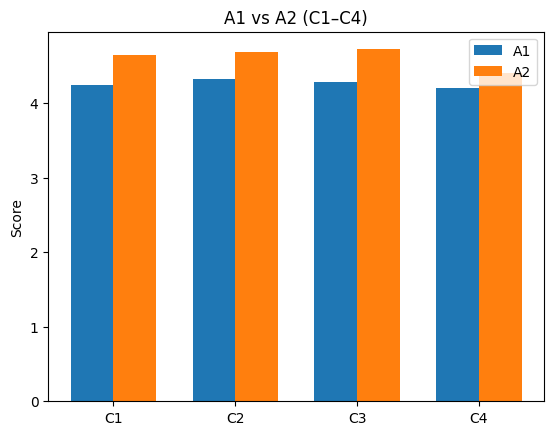

In [162]:
labels = ["C1","C2","C3","C4"]
x = range(len(labels))
width = 0.35

plt.figure()

plt.bar([i - width/2 for i in x], a1_avg.values, width=width, label="A1")
plt.bar([i + width/2 for i in x], a2_avg.values, width=width, label="A2")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("A1 vs A2 (C1–C4)")
plt.legend()

plt.show()

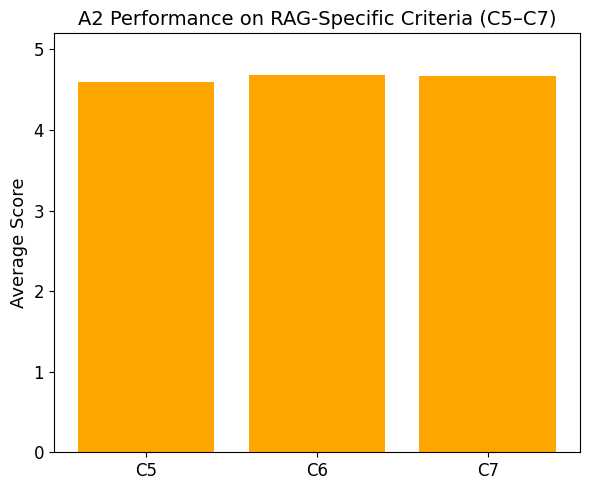

In [174]:
# CELL — RAG Chart (C5–C7)

plt.figure(figsize=(6,5))

plt.bar(
    ["C5", "C6", "C7"],
    a2_rag_avg.values,
    color="orange"
)

plt.ylabel("Average Score", fontsize=13)
plt.ylim(0, 5.2)
plt.title("A2 Performance on RAG-Specific Criteria (C5–C7)", fontsize=14)

# Optional: make x-axis labels bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Confusion matrices

In [ ]:
# Add labels manually

labels_data = [
# ID , Expected , A1 , A2
["TC01","Self-care","Self-care","Self-care"],
["TC02","Self-care","Self-care","Self-care"],
["TC03","Routine","Routine","Routine"],
["TC04","Urgent","Urgent","Urgent"],
["TC05","Routine","Routine","Routine"],
["TC06","Urgent","Urgent","Urgent"],
["TC07","Urgent","Urgent","Urgent"],
["TC08","Urgent","Urgent","Urgent"],
["TC09","Urgent","Urgent","Urgent"],
["TC10","Urgent","Urgent","Urgent"],
["TC11","Routine","Routine","Self-care"],
["TC12","Urgent","Urgent","Urgent"],
["TC13","Urgent","Urgent","Urgent"],
["TC14","Urgent","Urgent","Urgent"],
["TC15","Urgent","Urgent","Urgent"],
["TC16","Urgent","Urgent","Urgent"],
["TC17","Self-care","Self-care","Self-care"],
["TC18","Urgent","Urgent","Urgent"],
["TC19","Routine","Urgent","Urgent"],
["TC20","Routine","Routine","Self-care"],
["TC21","Routine","Routine","Routine"],
["TC22","Urgent","Urgent","Urgent"],
["TC23","Routine","Urgent","Urgent"],
["TC24","Urgent","Urgent","Urgent"],
["TC25","Urgent","NA","Urgent"],
]

df_labels = pd.DataFrame(labels_data, columns=["ID","Expected","A1","A2"])

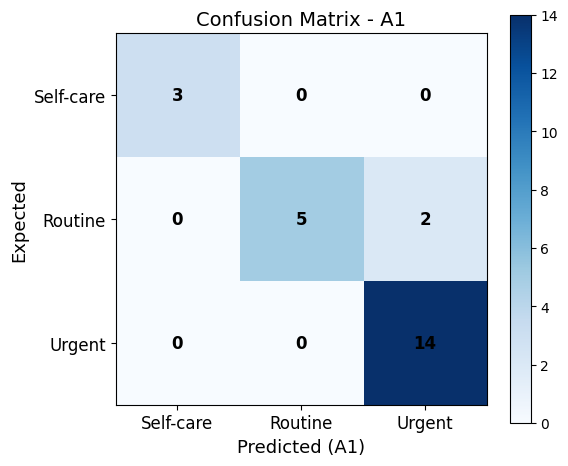

In [172]:
classes = ["Self-care","Routine","Urgent"]

cm_a1 = pd.crosstab(df_labels["Expected"], df_labels["A1"], dropna=False)
cm_a1 = cm_a1.reindex(index=classes, columns=classes, fill_value=0)

plt.figure(figsize=(6,5))  # 👈 bigger figure

plt.imshow(cm_a1, cmap="Blues")

# Bigger ticks
plt.xticks(range(len(classes)), classes, fontsize=12)
plt.yticks(range(len(classes)), classes, fontsize=12)

# Bigger labels + title
plt.xlabel("Predicted (A1)", fontsize=13)
plt.ylabel("Expected", fontsize=13)
plt.title("Confusion Matrix - A1", fontsize=14)

# Bigger numbers inside cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm_a1.iloc[i, j],
                 ha="center", va="center",
                 fontsize=12, fontweight="bold")

plt.colorbar()

plt.tight_layout()
plt.show()

A2 Confusion Matrix:
 A2         Self-care  Routine  Urgent
Expected                             
Self-care          3        0       0
Routine            2        3       2
Urgent             0        0      15


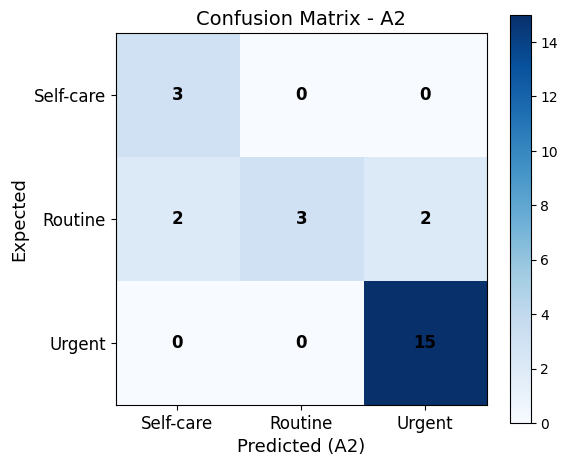

In [173]:
cm_a2 = pd.crosstab(df_labels["Expected"], df_labels["A2"], dropna=False)
cm_a2 = cm_a2.reindex(index=classes, columns=classes, fill_value=0)

print("A2 Confusion Matrix:\n", cm_a2)

plt.figure(figsize=(6,5))  # bigger figure

plt.imshow(cm_a2, cmap="Blues")  

# Bigger ticks
plt.xticks(range(len(classes)), classes, fontsize=12)
plt.yticks(range(len(classes)), classes, fontsize=12)

# Labels + title
plt.xlabel("Predicted (A2)", fontsize=13)
plt.ylabel("Expected", fontsize=13)
plt.title("Confusion Matrix - A2", fontsize=14)

# Numbers inside cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm_a2.iloc[i, j],
                 ha="center", va="center",
                 fontsize=12, fontweight="bold")

plt.colorbar()

plt.tight_layout()
plt.show()